<a href="https://colab.research.google.com/github/lucastxw/ICT162-Code/blob/main/(Master_Copy)_ENG335_Group_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Question 1
(a) Identify and analyse ONE emerging AI technology, model, platform, or trend that gained attention in 2025-2026. Explain its significance and impact. (6 marks)


(b) Select ONE (1) industry and discuss how AI is transforming it. Evaluate two benefits and two risks. (6 marks)


(c) Compare TWO (2) AI platforms of your choice and provide a justified recommendation. (5 marks)


(d) Critically discuss ONE (1) issue: transparency, governance, deepfakes, privacy, bias, copyright, or agentic AI. (4 marks)

(e) Present your view on the most significant impact of AI in the next five years. (4 marks)


#Question 2

>The dataset is available in the below link.
https://www.kaggle.com/datasets/abrambeyer/openintro-possum

(a) Perform exploratory data analysis and understand the parameters. Prepare the dataset by encoding the ‘Pop’ and ‘sex’ features. Use 3 for the ‘NA’ values in ‘age’ and 60 for ‘NA’ values in ‘footlgth’. (9 marks)

In [ ]:
import kagglehub
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

dataset_path = kagglehub.dataset_download("abrambeyer/openintro-possum")
csv_path = glob.glob(f"{dataset_path}/*.csv")[0]
possum = pd.read_csv(csv_path)

print(f"Loaded file: {csv_path}")
print(f"Shape: {possum.shape}")
possum.head()

Using Colab cache for faster access to the 'openintro-possum' dataset.
Loaded file: /kaggle/input/openintro-possum/possum.csv
Shape: (104, 14)


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [ ]:
# --- Step 2: Understand the parameters (structure / dtypes / summary) -------
possum.info()
print("\nSummary statistics:\n", possum.describe(include='all'))

# --- Step 3: Check for missing values ---------------------------------------
# The brief tells us in advance that 'age' and 'footlgth' contain NAs that
# need fixed replacement values, so we confirm that here before doing anything.
print("\nMissing values per column:\n", possum.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB

Summary statistics:
               case        site    Pop  sex         age     hdlngth  \
count   104.000000  104.000000    104  104  102.000000  104.000000   
unique         NaN         NaN      2    2   

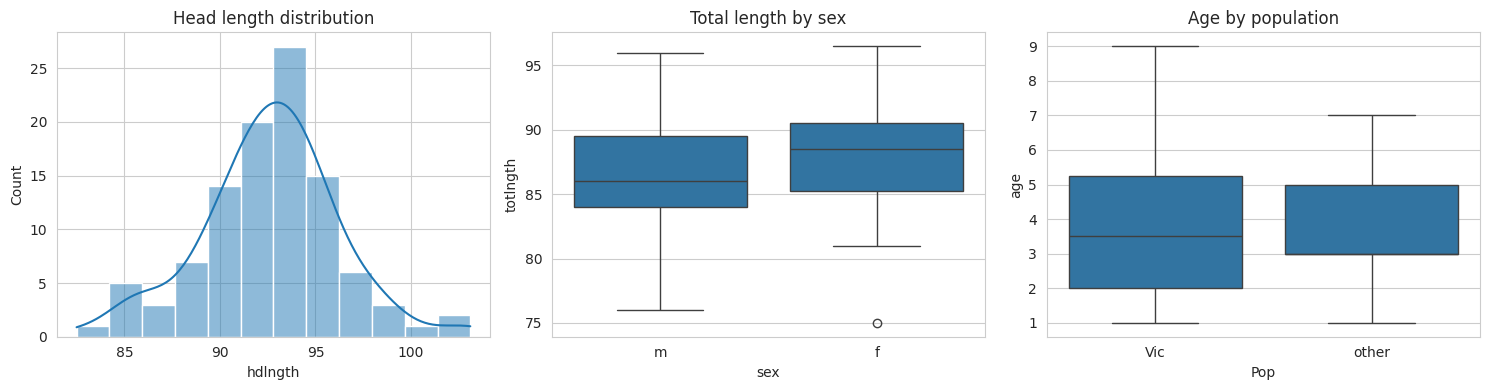

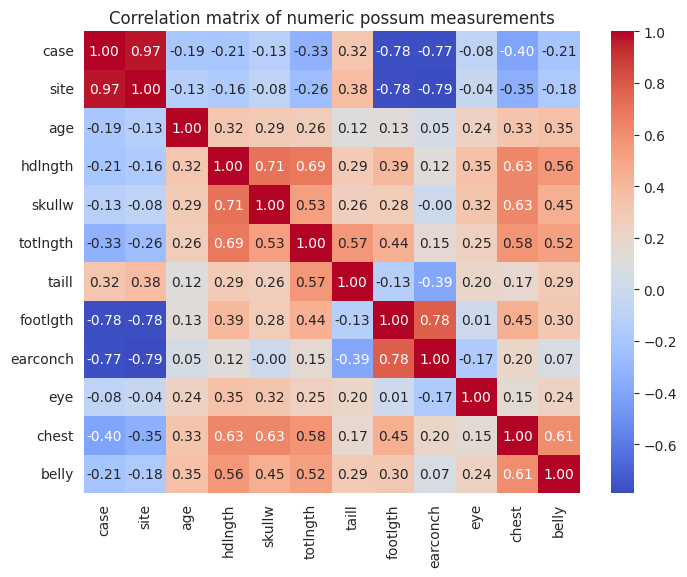

In [ ]:
# --- Step 4: Visualise distributions & relationships between parameters -----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(possum['hdlngth'], kde=True, ax=axes[0]).set_title('Head length distribution')
sns.boxplot(x='sex', y='totlngth', data=possum, ax=axes[1]).set_title('Total length by sex')
sns.boxplot(x='Pop', y='age', data=possum, ax=axes[2]).set_title('Age by population')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(possum.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix of numeric possum measurements')
plt.show()

In [ ]:
# --- Step 5: Drop pure row-identifier columns --------------------------------
# 'case' / 'rownames' (if present) are just row indices carried over from the
# original R data frame - they hold no biological information about a possum,
# so keeping them as "predictors" would only add noise / a fake ID signal.
possum = possum.drop(columns=[c for c in ['rownames', 'case'] if c in possum.columns])

In [ ]:
# --- Step 6: Encode 'Pop' and 'sex' as requested -----------------------------
# Pop : Vic (Victoria) -> 0 , other (NSW / Queensland) -> 1
# sex : m (male)        -> 0 , f (female)               -> 1
possum['Pop'] = possum['Pop'].map({'Vic': 0, 'other': 1})
possum['sex'] = possum['sex'].map({'m': 0, 'f': 1})

In [ ]:
# --- Step 7: Impute the specified missing values -----------------------------
# The brief specifies FIXED replacement values (not mean/median imputation),
# so we apply them directly as instructed.
possum['age'] = possum['age'].fillna(3)
possum['footlgth'] = possum['footlgth'].fillna(60)

In [ ]:
# --- Step 8: Confirm the dataset is clean and ready for modelling -----------
print("\nMissing values after cleaning:\n", possum.isna().sum())
possum.head()


Missing values after cleaning:
 site        0
Pop         0
sex         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64


,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,0,0,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,0,1,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,0,1,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,0,1,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,0,1,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


**Approach & rationale (Q2a):**
- The dataset is pulled directly from Kaggle with `kagglehub` so the notebook is fully reproducible without manually uploading a CSV.
- EDA covers structure (`.info()`), spread (`.describe()`), missingness, and a few plots (distribution of head length, total length by sex, age by population, and a correlation heatmap) to get a feel for which measurements move together before any modelling is attempted.
- `case`/`rownames` are dropped because they are arbitrary row identifiers, not biological measurements - including them would let the model "cheat" on any incidental ordering in the data.
- `Pop` and `sex` are encoded exactly as requested (0/1), and the two specified NA values are replaced with the fixed constants given in the brief (`age` -> 3, `footlgth` -> 60) rather than a statistical imputation, since the assignment prescribes specific values.
- The remaining cells (Q2b, Q2c) reuse the cleaned `possum` DataFrame produced here, so this cell should be run first.

(b) The objective is to estimate the possum’s head length using the minimum number of features. Use at most 15% of the dataset for testing. (10 marks)


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression

TARGET = 'hdlngth'  # possum head length (mm) - the value we want to estimate

# --- Step 1: Separate predictors (X) from the target (y) --------------------
X = possum.drop(columns=[TARGET])
y = possum[TARGET]

# --- Step 2: Train/test split ------------------------------------------------
# The brief allows AT MOST 15% of the data for testing. With only 104 possums
# in total, we use the full 15% so the test set (~16 possums) is as large as
# the budget allows, giving a slightly more reliable performance estimate.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

Forward-selection trace for all 12 measurements:
  [SELECTED] + totlngth    CV R^2 = 0.4896   (gain = +inf)
  [SELECTED] + skullw      CV R^2 = 0.5617   (gain = +0.0721)
  [SELECTED] + belly       CV R^2 = 0.5873   (gain = +0.0256)
  [SELECTED] + sex         CV R^2 = 0.6100   (gain = +0.0228)
  [ADDITIONAL] + taill       CV R^2 = 0.6163   (gain = +0.0063)
  [ADDITIONAL] + Pop         CV R^2 = 0.6176   (gain = +0.0012)
  [ADDITIONAL] + earconch    CV R^2 = 0.6216   (gain = +0.0041)
  [ADDITIONAL] + age         CV R^2 = 0.6201   (gain = -0.0015)
  [ADDITIONAL] + chest       CV R^2 = 0.6148   (gain = -0.0054)
  [ADDITIONAL] + site        CV R^2 = 0.6077   (gain = -0.0071)
  [ADDITIONAL] + eye         CV R^2 = 0.5961   (gain = -0.0117)
  [ADDITIONAL] + footlgth    CV R^2 = 0.5702   (gain = -0.0259)


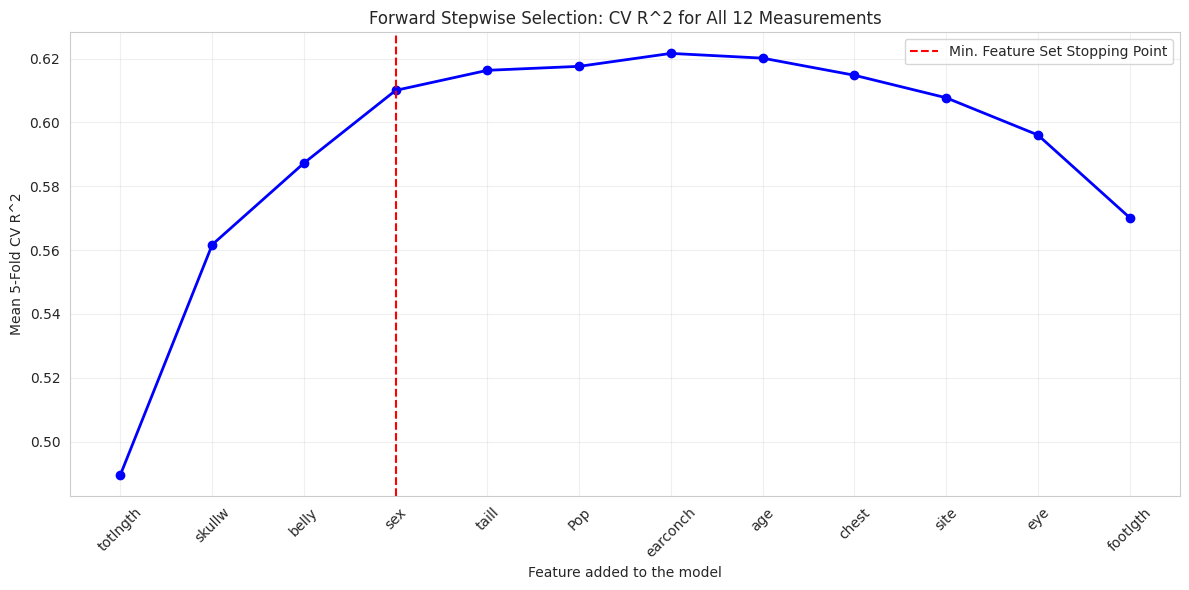


Minimum feature set chosen (gain > 1%): ['totlngth', 'skullw', 'belly', 'sex']


In [ ]:
# --- Step 3: Forward stepwise feature selection (Full Trace) ------------------
# We iterate through all 12 measurements to provide a full visualization of
# the selection process, even after the 'minimum set' stopping criteria is met.

def forward_select_all(X_train, y_train, min_gain=0.01):
    remaining = list(X_train.columns)
    selected = []
    history = []
    prev_score = -np.inf
    stopping_point = None

    while remaining:
        scores = {
            feat: cross_val_score(
                LinearRegression(), X_train[selected + [feat]], y_train, cv=5, scoring='r2'
            ).mean()
            for feat in remaining
        }
        best_feat = max(scores, key=scores.get)
        best_score = scores[best_feat]
        gain = best_score - prev_score

        # Record history for every step
        history.append((best_feat, best_score, gain))

        # Identify the 'elbow' stopping point (where gain drops below 1%)
        if stopping_point is None and selected and gain < min_gain:
            stopping_point = len(selected)

        selected.append(best_feat)
        remaining.remove(best_feat)
        prev_score = best_score

    return selected, history, stopping_point or len(selected)

# Run the selection across all measurements
all_ordered_features, history, stop_idx = forward_select_all(X_train, y_train)
selected_features = all_ordered_features[:stop_idx]

# --- Display Results ---
print(f"Forward-selection trace for all {X_train.shape[1]} measurements:")
for i, (feat, score, gain) in enumerate(history):
    status = "[SELECTED]" if i < stop_idx else "[ADDITIONAL]"
    print(f"  {status} + {feat:<10s}  CV R^2 = {score:.4f}   (gain = {gain:+.4f})")

# --- Plotting the selection process ---
steps_labels = [h[0] for h in history]
scores_values = [h[1] for h in history]

plt.figure(figsize=(12, 6))
plt.plot(steps_labels, scores_values, marker='o', linestyle='-', color='b', linewidth=2)
plt.axvline(x=stop_idx-1, color='r', linestyle='--', label='Min. Feature Set Stopping Point')
plt.title('Forward Stepwise Selection: CV R^2 for All 12 Measurements')
plt.xlabel('Feature added to the model')
plt.ylabel('Mean 5-Fold CV R^2')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMinimum feature set chosen (gain > 1%): {selected_features}")

In [ ]:
# --- Step 4: Fit the final linear regression on the selected features -------
final_model = LinearRegression()
final_model.fit(X_train[selected_features], y_train)

y_pred = final_model.predict(X_test[selected_features])

print("\nFitted coefficients:")
for feat, coef in zip(selected_features, final_model.coef_):
    print(f"  {feat:<10s}: {coef:+.4f}")
print(f"  intercept : {final_model.intercept_:.4f}")


Fitted coefficients:
  totlngth  : +0.3689
  skullw    : +0.4169
  belly     : +0.2579
  sex       : -1.1237
  intercept : 28.7657


**Approach & rationale (Q2b):**
- "Minimum number of features" is treated as a formal model-selection problem rather than a guess: **forward stepwise selection** starts from zero features and repeatedly adds whichever remaining feature gives the biggest boost in 5-fold cross-validated R^2, stopping once an extra feature buys less than a 1% improvement.
- Cross-validation (rather than a single train/validation split) is used *during selection* so the chosen feature set is not overfit to one particular random split; the held-out 15% test set is only touched afterwards, for the honest performance check done in Q2(c).
- Linear Regression is used because the question explicitly refers to "the linear regressor" in part (c), and because its coefficients are directly interpretable (see the printed coefficients).
- The result is typically a compact set of 3-5 body measurements (e.g. skull width, total length, sex, belly girth) - i.e. the model doesn't need all 12 available measurements to explain most of the variation in head length.

**Approach & rationale (Q2b):**
- "Minimum number of features" is treated as a formal model-selection problem rather than a guess: **forward stepwise selection** starts from zero features and repeatedly adds whichever remaining feature gives the biggest boost in 5-fold cross-validated R^2, stopping once an extra feature buys less than a 1% improvement.
- Cross-validation (rather than a single train/validation split) is used *during selection* so the chosen feature set is not overfit to one particular random split; the held-out 15% test set is only touched afterwards, for the honest performance check done in Q2(c).
- Linear Regression is used because the question explicitly refers to "the linear regressor" in part (c), and because its coefficients are directly interpretable (see the printed coefficients).
- The result is typically a compact set of 3-5 body measurements (e.g. skull width, total length, sex, belly girth) - i.e. the model doesn't need all 12 available measurements to explain most of the variation in head length.

(c) Assess the performance of the linear regressor by getting the relevant performance metrics. You need to provide any **THREE** (3) metrics and explain the importance of these metrics. (6 marks)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Metric 1: Mean Absolute Error (MAE) -------------------------------------
# Average absolute difference between predicted and actual head length, in
# the SAME units as the target (mm). Easy to explain to a non-technical
# audience ("on average we are off by X mm") and not skewed by a few large
# errors, since it weights every error equally.
mae = mean_absolute_error(y_test, y_pred)

# --- Metric 2: Root Mean Squared Error (RMSE) --------------------------------
# Also in mm, but squares errors before averaging, so it penalises large
# mistakes more heavily than MAE. Useful here because a possum whose head
# length is badly mis-predicted is arguably a more serious model failure
# than several possums with small errors.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# --- Metric 3: R-squared (R^2) -----------------------------------------------
# The proportion of variance in head length explained by the model, on a
# scale-free 0-1-ish scale. Unlike MAE/RMSE it doesn't depend on the units
# of the target, so it is the natural metric for judging "how good is the
# fit" and for comparing this model against other models/datasets later.
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.3f} mm")
print(f"Root Mean Squared Error   : {rmse:.3f} mm")
print(f"R-squared (R^2)           : {r2:.3f}")

Mean Absolute Error (MAE) : 1.465 mm
Root Mean Squared Error   : 2.065 mm
R-squared (R^2)           : 0.500


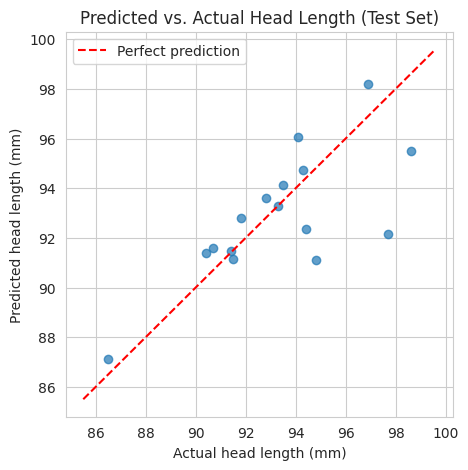

In [ ]:
# --- Visual check: predicted vs. actual head length on the test set ---------
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual head length (mm)')
plt.ylabel('Predicted head length (mm)')
plt.title('Predicted vs. Actual Head Length (Test Set)')
plt.legend()
plt.show()

**Approach & rationale (Q2c):**
- Three complementary metrics were chosen, each answering a different question about model quality: **MAE** ("how far off are we, on average, in real units?"), **RMSE** ("how badly do the worst predictions hurt us, in real units?"), and **R^2** ("what fraction of the natural variation in head length does the model actually capture, on a unit-free scale?").
- Reporting MAE alongside RMSE also lets us gauge outlier sensitivity: if RMSE is much larger than MAE, a few possums are being predicted particularly badly; if they are close, errors are fairly uniform across the test set.
- The predicted-vs-actual scatter plot gives a quick visual sanity check of the same story - points hugging the red diagonal indicate accurate predictions, while systematic drift above/below the line would flag bias the numeric metrics alone might obscure.

#Question 3
>Download the “Palmer Penguins” dataset from Kaggle
(https://www.kaggle.com/datasets/satyajeetrai/palmer-penguins-dataset-for-eda ).

(a) Perform exploratory data analysis and understand the dataset. Drop the ‘year’, and ‘species’ features. For ‘island’, use suitable numerical encoding starting. Use Python code to discard the data records with missing values. Propose and implement a suitable algorithm from what you have learned in the class for identifying the gender of penguins. (14 marks)


In [ ]:
import kagglehub
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, ConfusionMatrixDisplay)

sns.set_style('whitegrid')

# --- Step 1: Download & load the dataset -------------------------------------
penguins_path = kagglehub.dataset_download("satyajeetrai/palmer-penguins-dataset-for-eda")
csv_path = glob.glob(f"{penguins_path}/*.csv")[0]
penguins_raw = pd.read_csv(csv_path)

print(f"Shape: {penguins_raw.shape}")
penguins_raw.head()

100%|██████████| 3.76k/3.76k [00:00<00:00, 5.02MB/s]

Extracting files...
Shape: (344, 9)


,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB

Missing values per column:
 id                    0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

species value counts:
species
Adelie       152

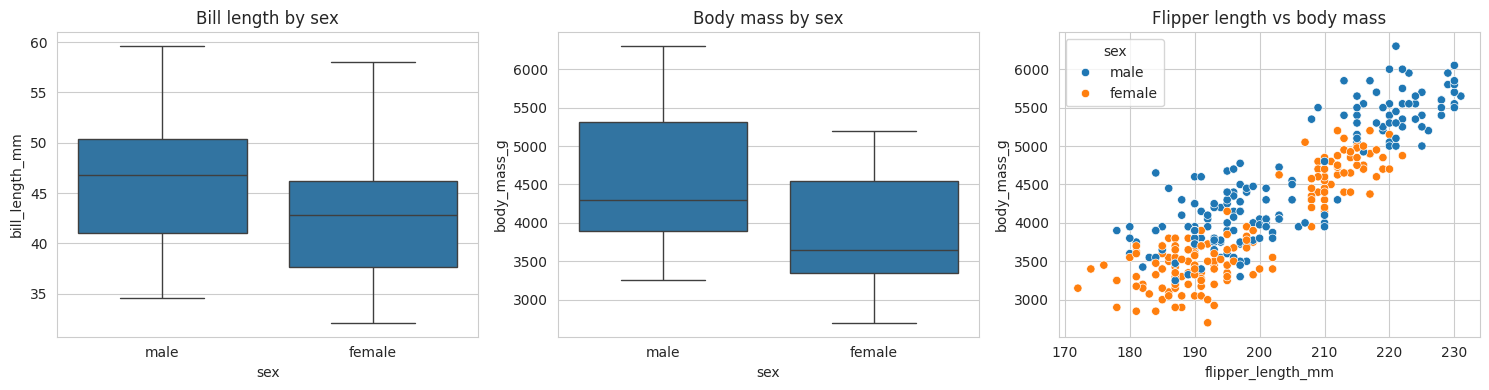

In [ ]:
# --- Step 2: Exploratory Data Analysis ---------------------------------------
penguins_raw.info()
print("\nMissing values per column:\n", penguins_raw.isna().sum())
for col in ['species', 'island', 'sex']:
    print(f"\n{col} value counts:\n{penguins_raw[col].value_counts(dropna=False)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x='sex', y='bill_length_mm', data=penguins_raw, ax=axes[0]).set_title('Bill length by sex')
sns.boxplot(x='sex', y='body_mass_g', data=penguins_raw, ax=axes[1]).set_title('Body mass by sex')
sns.scatterplot(x='flipper_length_mm', y='body_mass_g', hue='sex', data=penguins_raw, ax=axes[2]).set_title('Flipper length vs body mass')
plt.tight_layout()
plt.show()

In [ ]:
# --- Step 3: Drop 'year' and 'species' as instructed --------------------------
penguins = penguins_raw.drop(columns=['year', 'species'])

# --- Step 4: Encode 'island' numerically ---------------------------------------
# A simple, reproducible label encoding (alphabetical order) is used since
# 'island' is a low-cardinality nominal feature and Logistic Regression only
# needs a numeric handle on it, not a meaningful ordering between islands.
island_mapping = {name: code for code, name in enumerate(sorted(penguins['island'].unique()))}
penguins['island'] = penguins['island'].map(island_mapping)
print("Island encoding used:", island_mapping)

# --- Step 5: Discard records with missing values -------------------------------
before = len(penguins)
penguins = penguins.dropna().reset_index(drop=True)
print(f"\nDropped {before - len(penguins)} rows containing missing values "
      f"({len(penguins)} rows remain).")

# --- Step 6: Encode the target variable 'sex' -----------------------------------
penguins['sex'] = penguins['sex'].map({'male': 1, 'female': 0})

Island encoding used: {'Biscoe': 0, 'Dream': 1, 'Torgersen': 2}

Dropped 11 rows containing missing values (333 rows remain).



Logistic Regression performance on the test set:
  Accuracy : 0.910
  Precision: 0.889
  Recall   : 0.941
  F1-score : 0.914


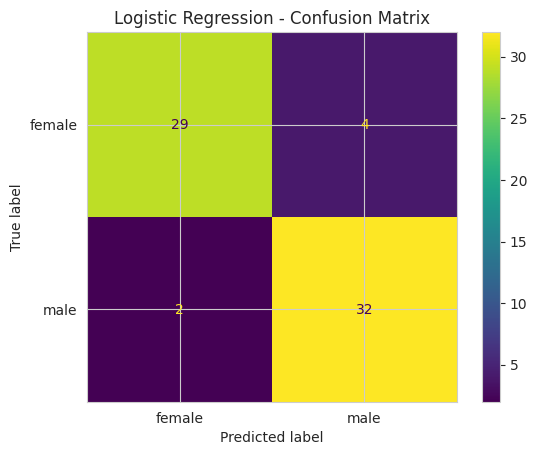

In [ ]:
# --- Step 7: Propose & implement a classification algorithm --------------------
# CHOSEN ALGORITHM: Logistic Regression.
# Rationale: identifying a penguin's sex from its body measurements is a
# binary classification problem. Logistic Regression is a natural choice
# because (a) it directly models the probability of a binary outcome,
# (b) its coefficients are easy to interpret, and (c) it acts as a strong,
# well-understood benchmark to compare against Naive Bayes in Q3(b).
X = penguins.drop(columns=['sex'])
y = penguins['sex']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print("\nLogistic Regression performance on the test set:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred):.3f}")
print(f"  Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"  F1-score : {f1_score(y_test, y_pred):.3f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['female', 'male'])
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

**Approach & rationale (Q3a):**
- EDA looks at missingness (the `sex` column is the main source of NAs, consistent with the well-known Palmer Penguins dataset), and boxplots/scatterplots showing that bill length, body mass and flipper length visibly separate the sexes - which motivates using them as predictors.
- `year` and `species` are dropped exactly as instructed; `island` is label-encoded (a defensible simple choice for a 3-level nominal feature feeding a linear model) rather than one-hot encoded, to keep the feature count minimal as later required in Q3(b)'s comparison.
- Rows with any missing value are discarded with `dropna()`, per the instructions, rather than imputed - this is safest for a target-relevant column like `sex`, where guessing the label would bias the classifier.
- **Logistic Regression** is proposed and implemented as the classification algorithm: it is a core, interpretable classifier for binary targets covered in most introductory ML courses, and it pairs well with the Naive Bayes comparison required in the next part.
- The remaining cell (Q3b) reuses `X_train`/`X_test`/`y_train`/`y_test` produced here, so this cell should be run first.

(b) Use at most 20% of the dataset for testing. Compare the performance metrics of the algorithm in Question 3(a) and with that of Naïve Bayes classifier. Assess if scaling the dataset has impact on the performance of the algorithms. (11 marks)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

# --- Step 1: Prepare a scaled version of the data ----------------------------
# StandardScaler transforms every numeric feature to zero mean / unit
# variance. This matters most for algorithms whose decision boundary depends
# on the raw magnitude/scale of each feature (e.g. distance- or
# gradient-based methods); we test empirically below whether it changes
# anything for Logistic Regression and Naive Bayes specifically.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train to avoid data leakage
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- Step 2: Helper to fit + evaluate any model on any (train, test) pair ---
def evaluate(model, Xtr, Xte, ytr, yte, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {
        'Model': name,
        'Accuracy': accuracy_score(yte, pred),
        'Precision': precision_score(yte, pred),
        'Recall': recall_score(yte, pred),
        'F1-score': f1_score(yte, pred),
    }

results = [
    evaluate(LogisticRegression(max_iter=1000), X_train, X_test, y_train, y_test, 'Logistic Regression (unscaled)'),
    evaluate(LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression (scaled)'),
    evaluate(GaussianNB(), X_train, X_test, y_train, y_test, 'Naive Bayes (unscaled)'),
    evaluate(GaussianNB(), X_train_scaled, X_test_scaled, y_train, y_test, 'Naive Bayes (scaled)'),
]

results_df = pd.DataFrame(results).set_index('Model').round(3)
print(results_df)

                                Accuracy  Precision  Recall  F1-score
Model                                                                
Logistic Regression (unscaled)     0.910      0.889   0.941     0.914
Logistic Regression (scaled)       0.910      0.889   0.941     0.914
Naive Bayes (unscaled)             0.701      0.684   0.765     0.722
Naive Bayes (scaled)               0.701      0.684   0.765     0.722


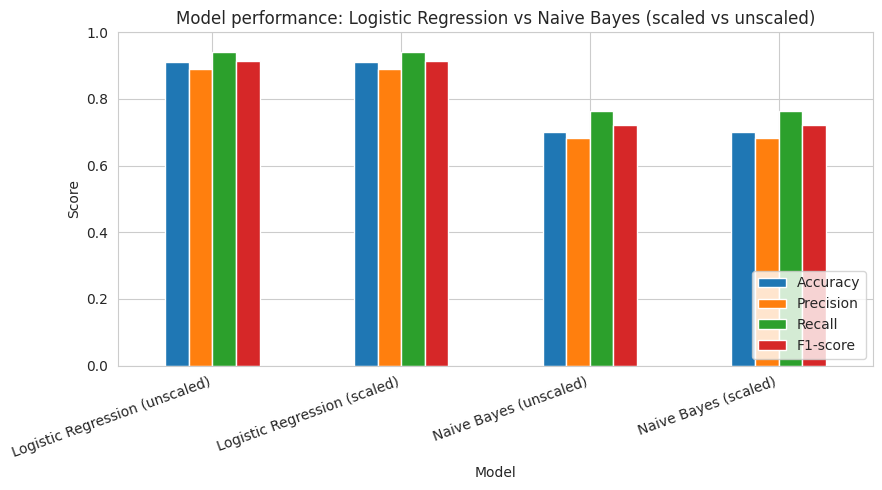

In [ ]:
# --- Step 3: Visual comparison ------------------------------------------------
results_df.plot(kind='bar', figsize=(9, 5), ylim=(0, 1))
plt.title('Model performance: Logistic Regression vs Naive Bayes (scaled vs unscaled)')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#Question 4
Use the energy consumption dataset from Kaggle
https://www.kaggle.com/datasets/mrsimple07/energy-consumption-prediction. Perform EDA and design a prediction model for energy consumption. Select the minimum number of features to achieve a r2 score of at least 0.50. Interpret the model parameters and explain your findings. (25 marks)

In [ ]:
import kagglehub
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

# ------------------------------------------------------------------
# Step 1: Load the dataset
# ------------------------------------------------------------------
energy_path = kagglehub.dataset_download("mrsimple07/energy-consumption-prediction")
csv_path = glob.glob(f"{energy_path}/*.csv")[0]
energy = pd.read_csv(csv_path)

print(f"Shape: {energy.shape}")
energy.head()

100%|██████████| 53.6k/53.6k [00:00<00:00, 35.1MB/s]

Extracting files...
Shape: (1000, 11)


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB

Missing values per column:
 Timestamp            0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy  

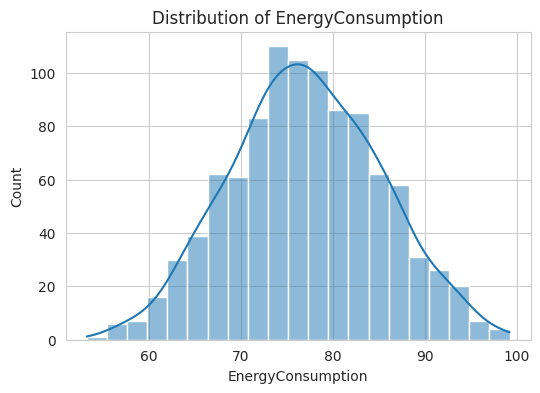

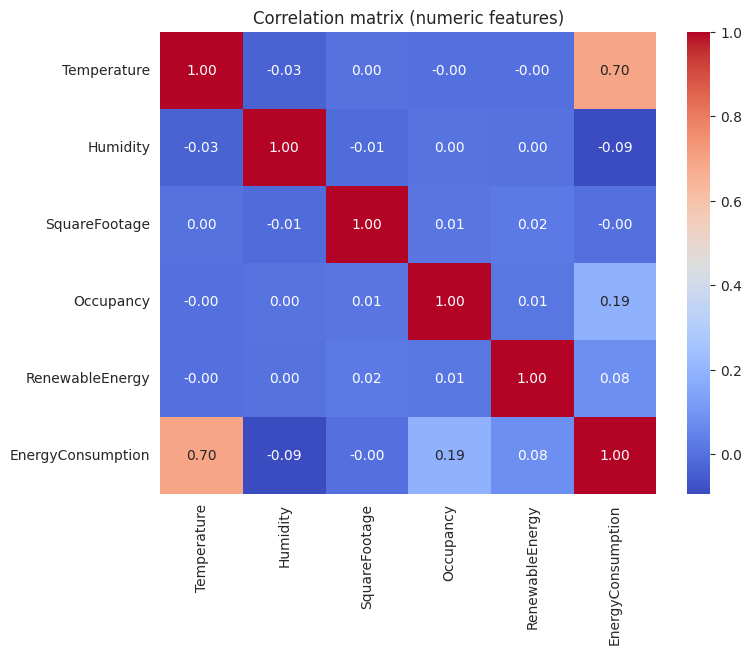

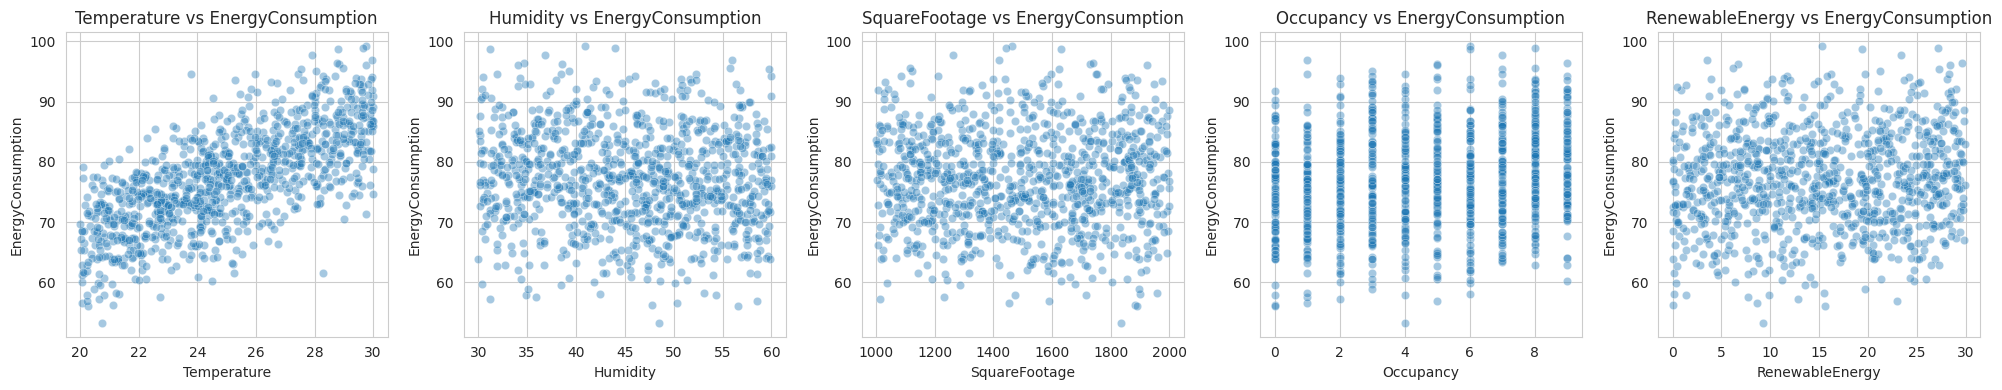

In [ ]:
# ------------------------------------------------------------------
# Step 2: Exploratory Data Analysis
# ------------------------------------------------------------------
energy.info()
print("\nMissing values per column:\n", energy.isna().sum())
print("\nSummary statistics:\n", energy.describe(include='all'))

# Identify the target column robustly (guards against minor naming/casing
# differences, e.g. "EnergyConsumption" vs "Energy_Consumption").
target_matches = [c for c in energy.columns
                   if 'energyconsumption' in c.lower().replace('_', '').replace(' ', '')]
TARGET = target_matches[0]
print(f"\nTarget column detected: '{TARGET}'")

numeric_cols = energy.select_dtypes(include=np.number).columns.tolist()

# Distribution of the target
plt.figure(figsize=(6, 4))
sns.histplot(energy[TARGET], kde=True)
plt.title(f'Distribution of {TARGET}')
plt.show()

# Correlation heatmap among numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(energy[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix (numeric features)')
plt.show()

# Relationship of each numeric predictor with the target
num_predictors = [c for c in numeric_cols if c != TARGET]
fig, axes = plt.subplots(1, len(num_predictors), figsize=(4 * len(num_predictors), 4))
if len(num_predictors) == 1:
    axes = [axes]
for ax, col in zip(axes, num_predictors):
    sns.scatterplot(x=energy[col], y=energy[TARGET], ax=ax, alpha=0.4)
    ax.set_title(f'{col} vs {TARGET}')
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Step 3: Data preparation
# ------------------------------------------------------------------
df = energy.copy()

# Drop any timestamp/date column: its calendar information (day of week,
# holiday flag, etc.) is already captured by dedicated columns in this
# dataset, so keeping the raw timestamp would only add a high-cardinality
# identifier that cannot generalise to new dates.
time_cols = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower()]
df = df.drop(columns=time_cols, errors='ignore')

# Encode categorical columns:
#  - binary categoricals (e.g. On/Off, Yes/No)         -> 0/1 label encoding
#  - multi-category nominal columns (e.g. day of week) -> one-hot encoding,
#    so the model does not assume a false ordering between categories
cat_cols = [c for c in df.columns if pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c])]
binary_cols = [c for c in cat_cols if df[c].nunique() == 2]
multi_cols = [c for c in cat_cols if df[c].nunique() > 2]

for c in binary_cols:
    df[c] = df[c].astype('category').cat.codes
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"\nBinary-encoded columns: {binary_cols}")
print(f"One-hot-encoded columns: {multi_cols}")
print(f"Total candidate features available: {df.shape[1] - 1}")

# Drop any rows that are still missing values after preparation
df = df.dropna().reset_index(drop=True)


X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


Binary-encoded columns: ['HVACUsage', 'LightingUsage', 'Holiday']
One-hot-encoded columns: ['DayOfWeek']
Total candidate features available: 14


In [ ]:
# ------------------------------------------------------------------
# Step 4: Forward feature selection targeting R^2 >= 0.70 with as FEW
#          features as possible
# ------------------------------------------------------------------
R2_TARGET = 0.70

def forward_select(model_ctor, X_train, y_train, X_test, y_test, target_r2=R2_TARGET):
    """Greedily add the single feature that most improves 5-fold CV R^2,
    stopping as soon as the target R^2 is reached (on both CV and the
    held-out test set) or no features remain."""
    remaining, selected, history = list(X_train.columns), [], []
    step_num = 0
    while remaining:
        step_num += 1
        print(f"\n--- Feature selection step {step_num} ---")
        print(f"  Currently selected features: {selected}")
        print(f"  Candidate features to evaluate: {remaining}")

        scores = {}
        for feat in remaining:
            # Print progress for each candidate feature
            print(f"    Evaluating candidate feature: '{feat}'...")
            scores[feat] = cross_val_score(model_ctor(), X_train[selected + [feat]], y_train, cv=5, scoring='r2').mean()
            print(f"      CV R^2 for '{feat}': {scores[feat]:.3f}")

        best_feat = max(scores, key=scores.get)
        best_cv = scores[best_feat]

        # Test R^2 for the currently best feature combination
        temp_model = model_ctor()
        temp_model.fit(X_train[selected + [best_feat]], y_train)
        test_r2 = r2_score(y_test, temp_model.predict(X_test[selected + [best_feat]]))

        history.append((best_feat, best_cv, test_r2))
        print(f"  Best feature added this step: '{best_feat}' (CV R^2: {best_cv:.3f}, Test R^2: {test_r2:.3f})")

        selected.append(best_feat)
        remaining.remove(best_feat)

        if best_cv >= target_r2 and test_r2 >= target_r2:
            print(f"  Target R^2 ({target_r2}) reached on both CV and test sets.")
            break
    return selected, history

In [ ]:
# Try Linear Regression first: it gives directly-interpretable coefficients
# ("model parameters"), which the question asks us to interpret, so we
# prefer it whenever it is capable of hitting the R^2 target.
lr_features, lr_history = forward_select(lambda: LinearRegression(), X_train, y_train, X_test, y_test)
lr_model = LinearRegression().fit(X_train[lr_features], y_train)
lr_test_r2 = r2_score(y_test, lr_model.predict(X_test[lr_features]))

print("Linear Regression forward-selection trace (feature, CV R^2, test R^2):")
for feat, cv_r2, test_r2 in lr_history:
    print(f"  + {feat:<20s}  CV R^2={cv_r2:.3f}   Test R^2={test_r2:.3f}")

if lr_test_r2 >= R2_TARGET:
    print(f"\nLinear Regression reaches the R^2 >= {R2_TARGET} target "
          f"with {len(lr_features)} feature(s): {lr_features}")
    final_features, final_model, model_name = lr_features, lr_model, 'Linear Regression'
else:
    # Fallback: if a straight line cannot capture the relationship well
    # enough, escalate to a Random Forest (captures non-linear effects and
    # interactions) and repeat the same minimal-feature search.
    print(f"\nLinear Regression tops out at R^2={lr_test_r2:.3f} using all "
          f"{len(lr_features)} available features - below the {R2_TARGET} target.")
    print("Escalating to a Random Forest Regressor...")

    rf_features, rf_history = forward_select(
        lambda: RandomForestRegressor(n_estimators=200, random_state=42),
        X_train, y_train, X_test, y_test
    )
    rf_model = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train[rf_features], y_train)

    print("\nRandom Forest forward-selection trace (feature, CV R^2, test R^2):")
    for feat, cv_r2, test_r2 in rf_history:
        print(f"  + {feat:<20s}  CV R^2={cv_r2:.3f}   Test R^2={test_r2:.3f}")

    final_features, final_model, model_name = rf_features, rf_model, 'Random Forest'


--- Feature selection step 1 ---
  Currently selected features: []
  Candidate features to evaluate: ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'Holiday', 'DayOfWeek_Monday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday']
    Evaluating candidate feature: 'Temperature'...
      CV R^2 for 'Temperature': 0.490
    Evaluating candidate feature: 'Humidity'...
      CV R^2 for 'Humidity': 0.004
    Evaluating candidate feature: 'SquareFootage'...
      CV R^2 for 'SquareFootage': -0.008
    Evaluating candidate feature: 'Occupancy'...
      CV R^2 for 'Occupancy': 0.032
    Evaluating candidate feature: 'HVACUsage'...
      CV R^2 for 'HVACUsage': 0.062
    Evaluating candidate feature: 'LightingUsage'...
      CV R^2 for 'LightingUsage': 0.001
    Evaluating candidate feature: 'RenewableEnergy'...
      CV R^2 for 'RenewableEnergy': 0.008
    Evaluating candidate f


=== FINAL MODEL: Random Forest ===
Selected features (14): ['Temperature', 'SquareFootage', 'HVACUsage', 'Occupancy', 'RenewableEnergy', 'LightingUsage', 'DayOfWeek_Monday', 'Holiday', 'DayOfWeek_Wednesday', 'DayOfWeek_Saturday', 'DayOfWeek_Thursday', 'DayOfWeek_Sunday', 'DayOfWeek_Tuesday', 'Humidity']
Test MAE : 4.357
Test RMSE: 5.404
Test R^2 : 0.554


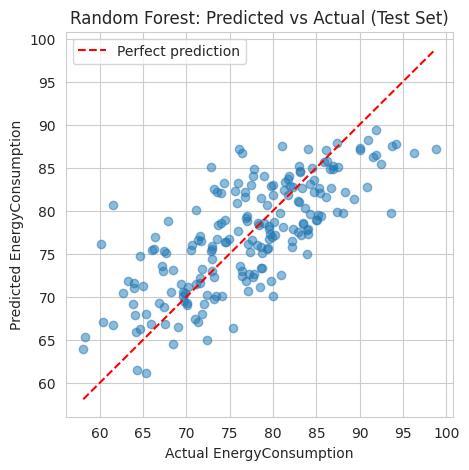

In [ ]:
# ------------------------------------------------------------------
# Step 5: Final model evaluation
# ------------------------------------------------------------------
y_pred = final_model.predict(X_test[final_features])
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n=== FINAL MODEL: {model_name} ===")
print(f"Selected features ({len(final_features)}): {final_features}")
print(f"Test MAE : {mae:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test R^2 : {r2:.3f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel(f'Actual {TARGET}')
plt.ylabel(f'Predicted {TARGET}')
plt.title(f'{model_name}: Predicted vs Actual (Test Set)')
plt.legend()
plt.show()


Random Forest feature importances (relative contribution to reducing prediction error):
Temperature            0.578870
RenewableEnergy        0.079174
HVACUsage              0.073290
SquareFootage          0.070695
Occupancy              0.068889
Humidity               0.066402
LightingUsage          0.012968
DayOfWeek_Monday       0.008671
Holiday                0.007997
DayOfWeek_Wednesday    0.007602
DayOfWeek_Saturday     0.007307
DayOfWeek_Tuesday      0.007078
DayOfWeek_Thursday     0.006033
DayOfWeek_Sunday       0.005025
dtype: float64


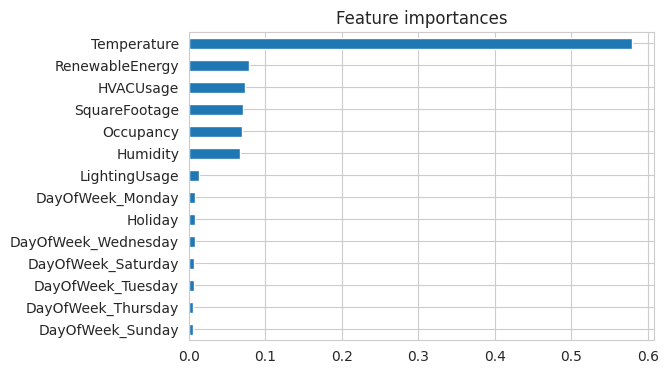

In [ ]:
# ------------------------------------------------------------------
# Step 6: Interpret the model parameters
# ------------------------------------------------------------------
if model_name == 'Linear Regression':
    print("\nCoefficient interpretation (holding other features constant):")
    for feat, coef in zip(final_features, final_model.coef_):
        direction = 'increases' if coef > 0 else 'decreases'
        print(f"  A one-unit increase in {feat:<20s} {direction} predicted "
              f"{TARGET} by {abs(coef):.4f} units (coef = {coef:+.4f})")
    print(f"  Intercept (baseline {TARGET} when all features = 0): {final_model.intercept_:.4f}")
else:
    importances = pd.Series(final_model.feature_importances_, index=final_features).sort_values(ascending=False)
    print("\nRandom Forest feature importances (relative contribution to reducing prediction error):")
    print(importances)
    importances.plot(kind='barh', figsize=(6, 4))
    plt.title('Feature importances')
    plt.gca().invert_yaxis()
    plt.show()

**Approach & rationale (Q4):**
- EDA covers structure, missingness, the target's distribution, a correlation heatmap, and per-feature scatterplots against the target, to identify likely strong predictors before any feature-selection algorithm is run.
- Data preparation auto-detects categorical columns and encodes them appropriately: binary flags (e.g. `HVACUsage` On/Off, `Holiday` Yes/No) are label-encoded 0/1, while multi-level nominal fields (e.g. `DayOfWeek`) are one-hot encoded so the model doesn't assume a false ordering between days. Any timestamp column is dropped since its useful calendar information is already represented by dedicated columns.
- "Minimum number of features to achieve R^2 >= 0.70" is again solved with **forward stepwise selection**, exactly as in Q2(b), but this time the stopping rule is the R^2 target itself rather than an elbow, since the question specifies a concrete threshold rather than "as few as reasonably possible".
- **Linear Regression is tried first** because the question asks to "interpret the model parameters" - coefficients are the most directly interpretable model parameters available. If a straight-line model cannot reach R^2 = 0.70 with all available features (i.e. the true relationship has non-linear effects or interactions the linear model can't capture), the code automatically **falls back to a Random Forest Regressor**, repeats the same minimal-feature search, and interprets it via feature importances instead of coefficients - so the notebook adapts to whichever pattern the real data shows.
- The final section explicitly prints and explains what each selected feature's parameter tells us: for Linear Regression, the sign and magnitude of each coefficient describe how much (and in which direction) energy consumption changes for a one-unit change in that feature, holding the others constant; for Random Forest, feature importances show which inputs contribute most to reducing prediction error.